WHAT IS THIS NOTEBOOK: It is the basics of everything that goes into Kibble_Zurek File and also has a few example test plots

WHAT USE IT FOR: PROBABLY nothing by now. SLATED FOR REMOVAL AFTER DOUBHLE CHECK


In [1]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm
import sys
sys.path.append("../../src/")
import kblock_ising_model as kb


In [2]:
###These Functions are given by 7.2.87-88 of "Quantum Ising Phases and Transitions"
###They represent the bogoliouv Transformation starting from t0 = - inf to a time tf with a speed related to tau. g goes from infinity to -infinity.


def u_tilde(tau,q,tf):
    """tau = quench time
    tf  =final time
    q   =momentum value
    eq. 7.2.87"""
    a = 1+cos(q)
    b = sin(q)

    rot = exp(-1j*3*pi/4)
    rot_inv = exp(1j*3*pi/4)
    decay = exp(-pi*b*b*tau/4)
    prefactor = rot*b*sqrt(tau)*decay
    argument = rot_inv*2*(tf-a*tau)/sqrt(tau)
    nu = 1j*b*b*tau-1
    #Can be unstable at large tau
    return prefactor*complex(pcfd(nu,argument))

def v_tilde(tau,q,t):
    """tau = quench time
    tf  =final time
    q   =momentum value
    eq. 7.2.88"""
    a = 1+cos(q)
    b = sin(q)
    rot = exp(-1j*3*pi/4)
    rot_inv = exp(1j*3*pi/4)
    decay = exp(-pi*b*b*tau/4)
    prefactor = -decay
    argument = rot_inv*2*(t-a*tau)/sqrt(tau)
    nu = 1j*b*b*tau
    #Can be unstable at large tau
    return prefactor*complex(pcfd(nu,argument))

In [92]:
##There is something currently wrong with these, but these are supposed to be the ground state bogoliouv transformation.

def u_diag(q,g):
    a = g+cos(q)
    omega= sqrt(g*g+2*g*cos(q)+1)

    denom = sqrt(2*omega*(omega-a))

    return (a - omega)/denom

def v_diag(q,g):
    a = g+cos(q)
    b = sin(q)
    omega= sqrt(g*g+2*g*cos(q)+1)

    denom = sqrt(2*omega*(omega-a))

    return b/denom

In [93]:

def k_vals(L):
    """Generates k values >0"""
    x=(2 * np.arange(-L//2, L//2) + 1) * np.pi / (L)
    return x[x>0]


def state(L,tau,t):
    """Generates state as [us, vs, k]"""
    #Generate momentum values
    k = k_vals(L)
    us = np.array([u_tilde(tau,q,t) for q in k])
    vs = np.array([v_tilde(tau,q,t) for q in k])
    return [us,vs,k]


def ground_state(L,tau,t):
    #Is supposed to generate ground state
    k = k_vals(L)
    us = np.array([v_diag(q,g(t,tau)) for q in k])
    vs = np.array([u_diag(q,g(t,tau)) for q in k])
    norm = sqrt(u**2+v**2)
    us /= norm
    vs /= norm
    return [us,vs,k]


def G(r,state):
    """r = integer
    state = [us, vs, k]
    calculates {bi,aj} correlation of r=j-i
    """
    u = state[0]
    v = state[1]
    k = state[2]
    #Equation 7.2.26a
    Gr = 2*cos(k*r)*(np.abs(u)**2-np.abs(v)**2)-2j*sin(k*r)*(np.conj(u)*v+v*np.conj(u))
    return -np.mean(Gr)/2

def D(n,state):
    """Strange Convention, n = r-1"""
    r = n+1
    return G(r,state)
def g(t,tau):
    return -t/tau + 1

In [94]:
def sigma_general(indices,state):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,state)
    return np.linalg.det(C)

In [95]:
##Projector Functions 
from itertools import combinations
from collections import Counter

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,state, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,state)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


In [96]:
def delta(state,args,n):
    KZ = P_n(n,state)
    GS = kb.P_n(n,*args)
    return abs(KZ-GS)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_13217/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


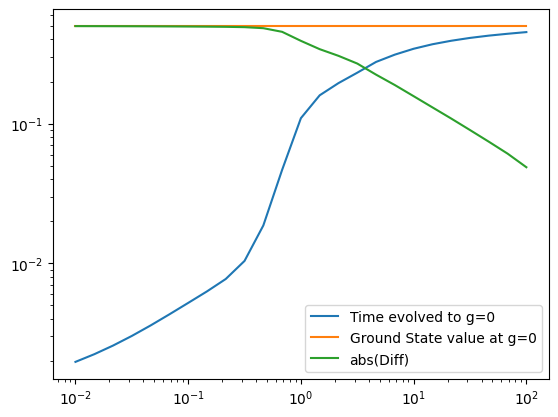

In [97]:
#Simple Test
L = 100
n = 10
taus = np.logspace(-2,2,25)
Kibble_Zurek = []
Ground_State = []
Delta_values = []

for tau in taus:
    t= tau
    state_t = state(L,tau,t)
    k0 = kb.k_vals(L)
    #U0 needs -g because of different conventions
    U0 = kb.U(k0,-g(t,tau))

    P_kz = P_n(n,state_t)
    P0 = kb.P_n(n,U0,k0)
    diff = delta(state_t,[U0,k0],n)

    Kibble_Zurek+= [P_kz]
    Ground_State += [P0]
    Delta_values += [diff]
plot(taus,Kibble_Zurek,label="Time evolved to g=0")
plot(taus,Ground_State,label="Ground State value at g=0")
plot(taus,Delta_values,label="abs(Diff)")
plt.legend()
plt.yscale("log")
plt.xscale("log")

# The above works well, don't mess with it

  0%|          | 0/8 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_13217/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 8/8 [00:14<00:00,  1.84s/it]


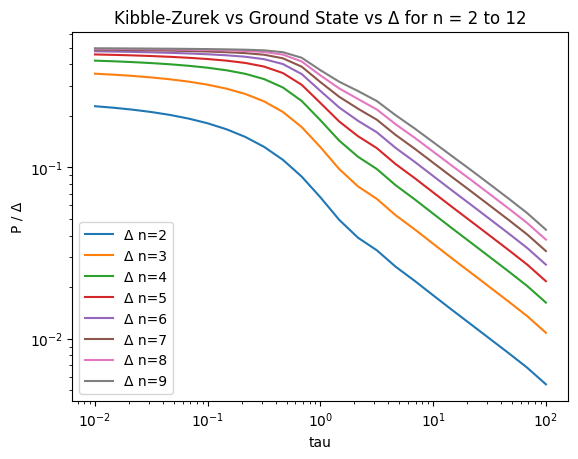

In [104]:
L = 100
taus = np.logspace(-2, 2, 25)
ns = range(2, 10)

for n in tqdm(ns):
    Kibble_Zurek = []
    Ground_State = []
    Delta_values = []

    for tau in taus:
        t = tau
        state_t = state(L, tau, t)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g(t, tau))

        P_kz = P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = delta(state_t, [U0, k0], n)

        Kibble_Zurek.append(P_kz)
        Ground_State.append(P0)
        Delta_values.append(diff)

   # plot(taus, Kibble_Zurek, label=f"KZ n={n}")
   # plot(taus, Ground_State, label=f"GS n={n}")
    plot(taus, Delta_values, label=f"Δ n={n}")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("P / Δ")
plt.title("Kibble-Zurek vs Ground State vs Δ for n = 2 to 12")
plt.show()


  0%|          | 0/8 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_13217/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 8/8 [04:17<00:00, 32.19s/it]


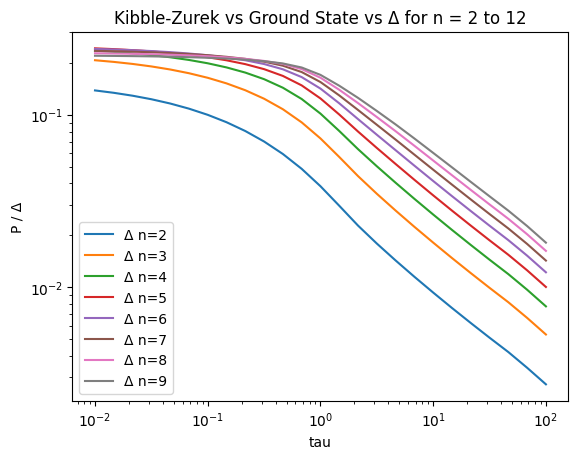

In [102]:
L = 100
taus = np.logspace(-2, 2, 25)
ns = range(2, 10)

for n in tqdm(ns):
    DV =[]
    for tau in tqdm(taus):
        Delta_values=[]
        for t in (np.linspace(-tau,tau,25)):
            state_t = state(L, tau, t)
            k0 = kb.k_vals(L)
            U0 = kb.U(k0, -g(t, tau))
            diff = delta(state_t, [U0, k0], n)
            Delta_values.append(diff)
        Delta_values = np.array(Delta_values)
        DV.append(np.mean(Delta_values))
    plot(taus, DV, label=f"Δ n={n}")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("P / Δ")
plt.title("Kibble-Zurek vs Ground State vs Δ for n = 2 to 12")
plt.show()


  0%|          | 0/25 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_13217/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 25/25 [00:43<00:00,  1.75s/it]


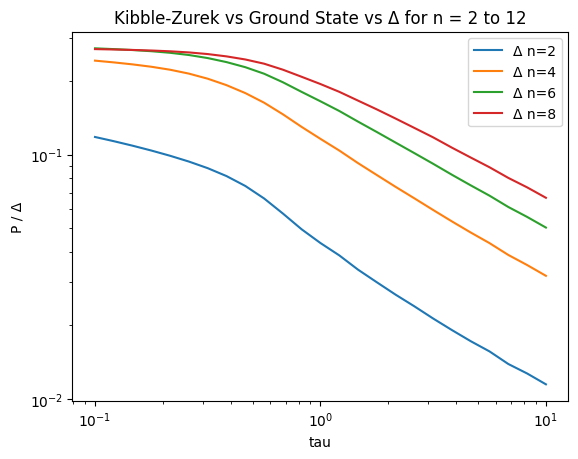

In [106]:
L = 100
taus = np.logspace(-1, 1, 25)
ns = range(2, 10,2)

for n in (ns):
    DV =[]
    for tau in tqdm(taus):
        Delta_values=[]
        for t in (np.linspace(-tau,2*tau,25)):
            state_t = state(L, tau, t)
            k0 = kb.k_vals(L)
            U0 = kb.U(k0, -g(t, tau))
            diff = delta(state_t, [U0, k0], n)
            Delta_values.append(diff)
        Delta_values = np.array(Delta_values)
        DV.append(np.mean(Delta_values))
    plot(taus, DV, label=f"Δ n={n}")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("P / Δ")
plt.title("Kibble-Zurek vs Ground State vs Δ for n = 2 to 12")
plt.show()


In [216]:
L = 100
taus = np.logspace(-2, 2, 50)
ns = range(2, 12, 2)

# Dictionary to store DV arrays per n
DV_dict = {n: [] for n in ns}

for tau in tqdm(taus):
    times = np.linspace(-tau, 2 * tau, 25)
    states = []

    for t in times:
        state_t = state(L, tau, t)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g(t, tau))
        states.append((state_t, U0, k0))

    for n in ns:
        Delta_values = []
        for state_t, U0, k0 in states:
            diff = delta(state_t, [U0, k0], n)
            Delta_values.append(diff)
        DV_dict[n].append(np.mean(Delta_values))




  0%|          | 0/50 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_13217/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 50/50 [05:32<00:00,  6.64s/it]


2
4
6
8
10


(0.1, 10)

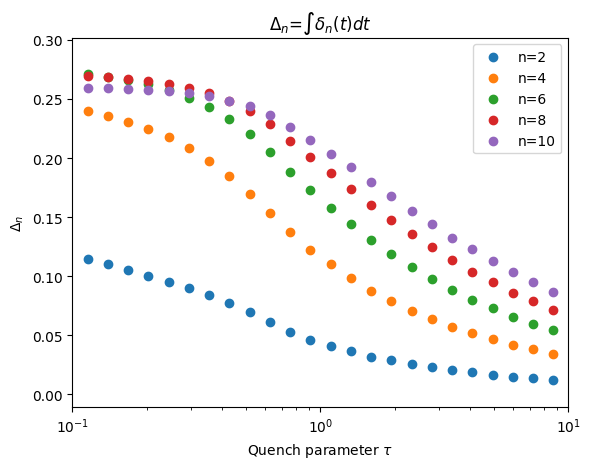

In [247]:
# Plot once after all DV values are collected
for n in ns:
    x = np.array(DV_dict[n])
    print(n)
    plt.scatter(taus, x*(n)**(-0), label=f"n={n}")

#plt.plot(taus,DV_dict[8][10]*taus**(-1/2)/taus[10]**(-1/2))
plt.legend()
plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"Quench parameter $\tau$")
plt.ylabel(r"$\Delta_n$")
plt.title(r"$\Delta_n$=$\int{\delta_n(t)}dt$")
plt.xlim(10**-1,10**1)